# Waveform overlay

Loads every `wave_*.csv` produced by `python -m ad3pulse sweep` and plots the
traces on top of each other, coloured by pulse height.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors, cm

# Point this at the sweep folder you want to inspect.
RUN_DIR = Path(r"runs\w10us_amp1p58-2p1_1550Vbias")

TIME_UNIT, TIME_LABEL = 1e6, "time (us, 0 = AWG start)"
sorted(p.name for p in RUN_DIR.glob("wave_*.csv"))[:5]

['wave_A1p58349V_W1em05s.csv',
 'wave_A1p58698V_W1em05s.csv',
 'wave_A1p58V_W1em05s.csv',
 'wave_A1p59047V_W1em05s.csv',
 'wave_A1p59396V_W1em05s.csv']

## Load

In [3]:
def load_capture(path):
    """Return (metadata dict, t, ch1, ch2) for one wave_*.csv file."""
    meta = {}
    with open(path, "r", encoding="utf-8") as fh:
        header = fh.readline().lstrip("#").strip()
    for item in header.split(","):
        if "=" not in item:
            continue
        key, value = item.split("=", 1)
        try:
            meta[key] = float(value)
        except ValueError:
            meta[key] = value
    data = np.loadtxt(path, delimiter=",", comments="#")
    return meta, data[:, 0], data[:, 1], data[:, 2]


captures = [load_capture(p) for p in sorted(RUN_DIR.glob("wave_*.csv"))]
captures.sort(key=lambda c: (c[0]["width_s"], c[0]["amplitude_V"]))
amplitudes = np.array([c[0]["amplitude_V"] for c in captures])
widths = np.array([c[0]["width_s"] for c in captures])
print(f"{len(captures)} captures, "
      f"{amplitudes.min():g}-{amplitudes.max():g} V, "
      f"{len(np.unique(widths))} width(s)")

150 captures, 1.58-2.1 V, 1 width(s)


## Overlay both channels

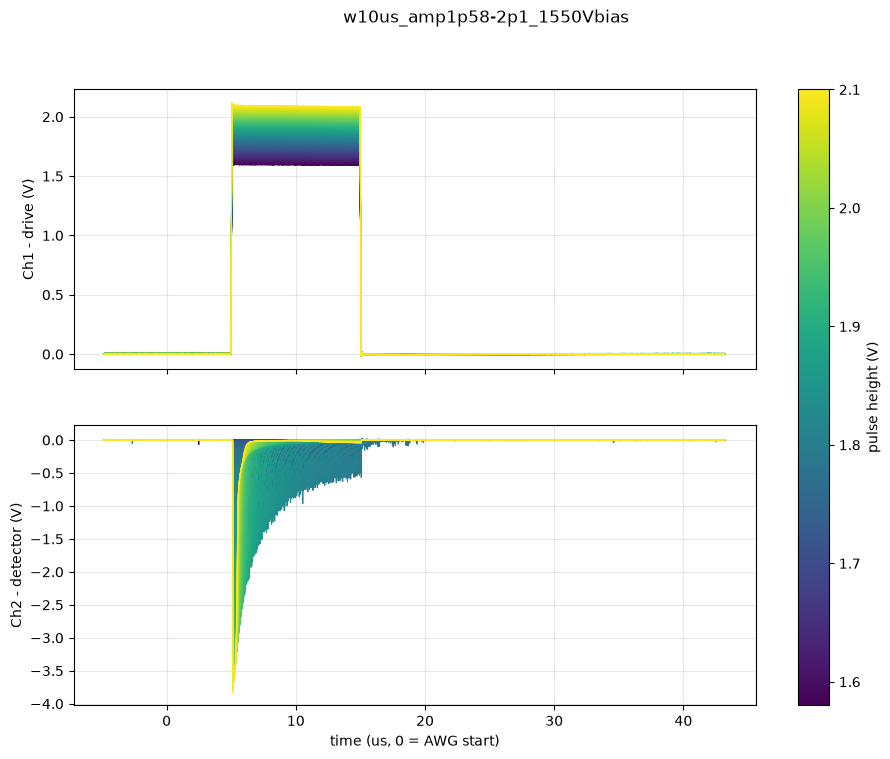

In [3]:
norm = colors.Normalize(amplitudes.min(), amplitudes.max())
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 8))
for meta, t, ch1, ch2 in captures:
    color = cmap(norm(meta["amplitude_V"]))
    axes[0].plot(t * TIME_UNIT, ch1, lw=0.7, color=color)
    axes[1].plot(t * TIME_UNIT, ch2, lw=0.7, color=color)

axes[0].set_ylabel("Ch1 - drive (V)")
axes[1].set_ylabel("Ch2 - detector (V)")
axes[1].set_xlabel(TIME_LABEL)
for ax in axes:
    ax.grid(alpha=0.3)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes,
             label="pulse height (V)")
fig.suptitle(RUN_DIR.name)
plt.show()

## Ch2 only, zoomed on the pulse

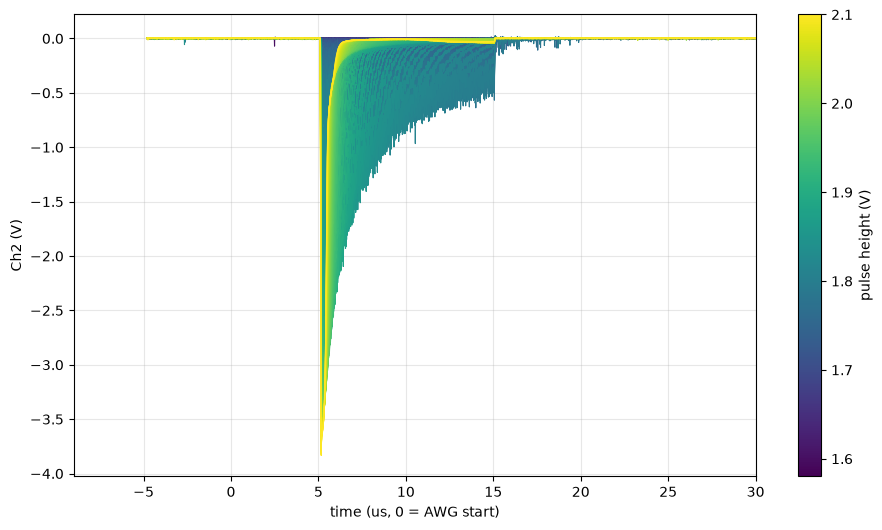

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
for meta, t, _ch1, ch2 in captures:
    ax.plot(t * TIME_UNIT, ch2, lw=0.8, color=cmap(norm(meta["amplitude_V"])))

pulse_end = float(np.max(widths)) * 3
ax.set_xlim(-pulse_end * TIME_UNIT * 0.3, pulse_end * TIME_UNIT)
ax.set_xlabel(TIME_LABEL)
ax.set_ylabel("Ch2 (V)")
ax.grid(alpha=0.3)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
             label="pulse height (V)")
plt.show()

## Response curve from `summary.csv`

Ch2 response against the measured Ch1 drive; departure from the dashed linear
fit of the low-amplitude points indicates saturation.

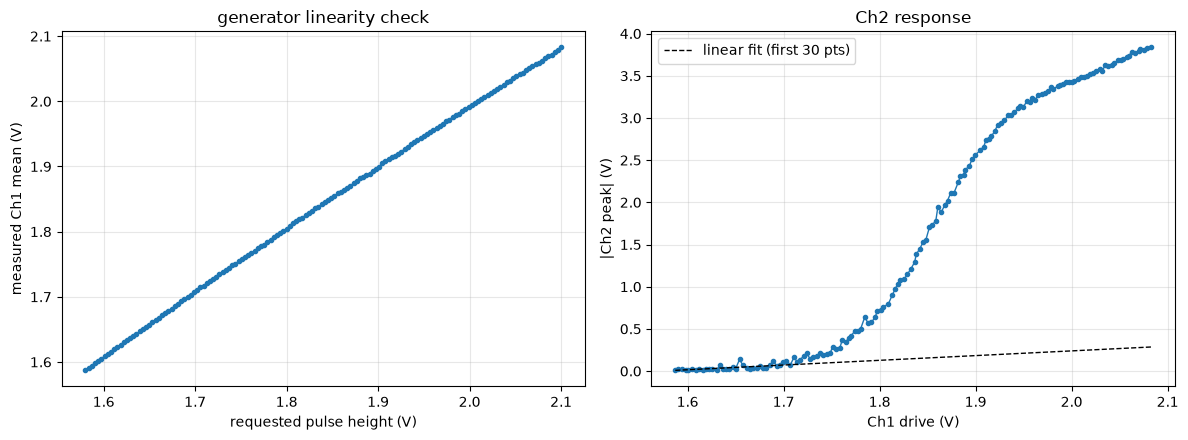

In [4]:
summary = np.genfromtxt(RUN_DIR / "summary.csv", delimiter=",", names=True,
                        dtype=None, encoding="utf-8")
order = np.argsort(summary["amplitude_set_V"])
drive = summary["ch1_mean_V"][order]
response = np.abs(summary["ch2_peak_V"][order])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(summary["amplitude_set_V"][order], drive, ".-", lw=1)
axes[0].set_xlabel("requested pulse height (V)")
axes[0].set_ylabel("measured Ch1 mean (V)")
axes[0].set_title("generator linearity check")

axes[1].plot(drive, response, ".-", lw=1)
n_fit = max(5, len(drive) // 5)
if n_fit < len(drive):
    slope, intercept = np.polyfit(drive[:n_fit], response[:n_fit], 1)
    axes[1].plot(drive, slope * drive + intercept, "k--", lw=1,
                 label=f"linear fit (first {n_fit} pts)")
    axes[1].legend()
axes[1].set_xlabel("Ch1 drive (V)")
axes[1].set_ylabel("|Ch2 peak| (V)")
axes[1].set_title("Ch2 response")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## LED voltage vs. integrated Ch2 signal

Drive circuit: AWG -> green LED -> 330 ohm resistor -> GND, with Ch1 monitoring
the drive pulse ("LED voltage"). The Ch2 integral is baseline-subtracted and
inverted so it comes out positive regardless of the detector's signal polarity.

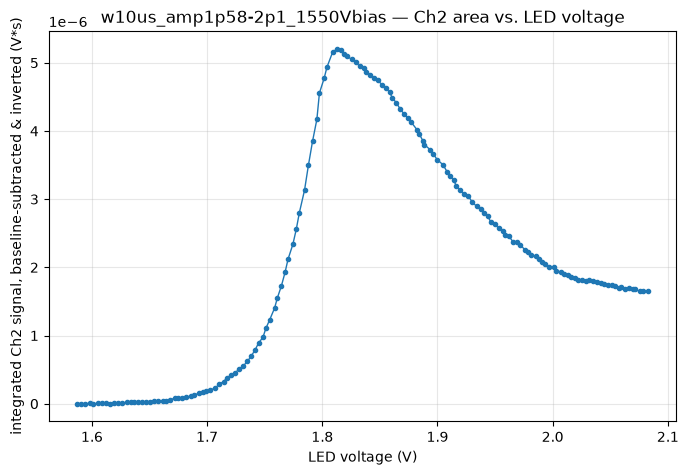

In [5]:
led_voltage_V = drive  # drive = ch1_mean_V, sorted by amplitude_set_V above
ch2_area_positive = -summary["ch2_area_Vs"][order]  # baseline-subtracted, inverted

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(led_voltage_V, ch2_area_positive, ".-", lw=1)
ax.set_xlabel("LED voltage (V)")
ax.set_ylabel("integrated Ch2 signal, baseline-subtracted & inverted (V*s)")
ax.set_title(f"{RUN_DIR.name} — Ch2 area vs. LED voltage")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Interactive walk-through: integral curve + raw waveform

Steps through the sweep points in order, showing where each one sits on the
LED-voltage vs. integral curve alongside its raw Ch2 waveform. Uses `ipympl`
(`%matplotlib widget`) so the figure stays live: a play button auto-advances,
the slider scrubs to any point, and the plot itself remains pannable/zoomable.

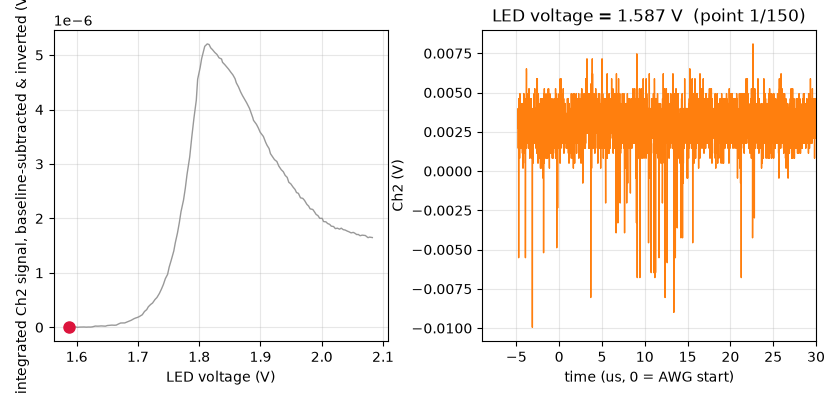

In [6]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

# Match each summary row (already sorted by amplitude_set_V, see `order`) to
# its raw waveform capture, keyed by pulse amplitude.
captures_by_amp = {round(meta["amplitude_V"], 9): (t, ch1, ch2)
                   for meta, t, ch1, ch2 in captures}
ordered_waves = [captures_by_amp[round(a, 9)]
                 for a in summary["amplitude_set_V"][order]]

fig, (ax_curve, ax_wave) = plt.subplots(1, 2, figsize=(8.4, 4))

ax_curve.plot(led_voltage_V, ch2_area_positive, "-", lw=1, color="0.6")
marker, = ax_curve.plot([], [], "o", color="crimson", ms=8, zorder=3)
ax_curve.set_xlabel("LED voltage (V)")
ax_curve.set_ylabel("integrated Ch2 signal, baseline-subtracted & inverted (V*s)")
ax_curve.grid(alpha=0.3)

wave_line, = ax_wave.plot([], [], lw=1, color="tab:orange")
ax_wave.set_xlabel(TIME_LABEL)
ax_wave.set_ylabel("Ch2 (V)")
ax_wave.grid(alpha=0.3)
pulse_end = float(np.max(widths)) * 3
ax_wave.set_xlim(-pulse_end * TIME_UNIT * 0.3, pulse_end * TIME_UNIT)
fig.tight_layout()


def update(i):
    marker.set_data([led_voltage_V[i]], [ch2_area_positive[i]])
    t, _ch1, ch2 = ordered_waves[i]
    wave_line.set_data(t * TIME_UNIT, ch2)
    # Rescale to this frame's own pulse height so the trace fills the axes.
    lo, hi = float(np.min(ch2)), float(np.max(ch2))
    pad = 0.05 * max(hi - lo, 1e-6)
    ax_wave.set_ylim(lo - pad, hi + pad)
    ax_wave.set_title(f"LED voltage = {led_voltage_V[i]:.3f} V  "
                       f"(point {i + 1}/{len(ordered_waves)})")
    fig.canvas.draw_idle()


n_points = len(ordered_waves)
slider = widgets.IntSlider(min=0, max=n_points - 1, value=0, description="point")
play = widgets.Play(min=0, max=n_points - 1, interval=120)

widgets.jslink((play, "value"), (slider, "value"))
display(widgets.HBox([play, slider]))

slider.observe(lambda change: update(change["new"]), names="value")
update(0)


## Same walk-through, fixed waveform y-axis

Identical to the cell above, but `ax_wave`'s y-axis is set once from the full
dataset's min/max instead of rescaling per frame — useful for comparing
absolute pulse heights across steps rather than shape at high resolution.

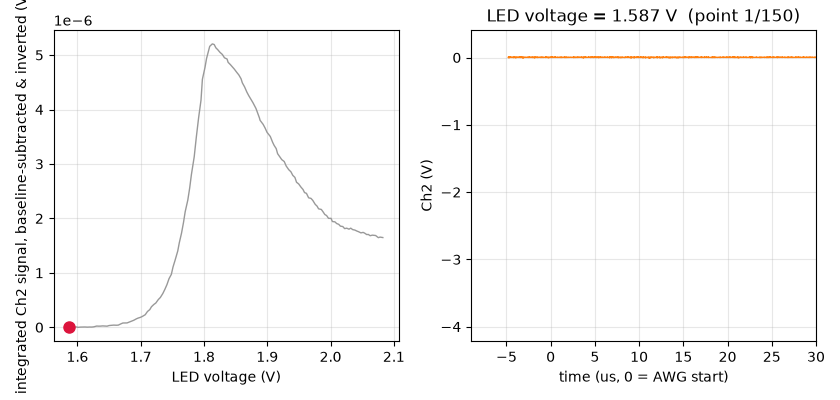

In [8]:
%matplotlib widget

fig2, (ax_curve2, ax_wave2) = plt.subplots(1, 2, figsize=(8.4, 4))

ax_curve2.plot(led_voltage_V, ch2_area_positive, "-", lw=1, color="0.6")
marker2, = ax_curve2.plot([], [], "o", color="crimson", ms=8, zorder=3)
ax_curve2.set_xlabel("LED voltage (V)")
ax_curve2.set_ylabel("integrated Ch2 signal, baseline-subtracted & inverted (V*s)")
ax_curve2.grid(alpha=0.3)

wave_line2, = ax_wave2.plot([], [], lw=1, color="tab:orange")
ax_wave2.set_xlabel(TIME_LABEL)
ax_wave2.set_ylabel("Ch2 (V)")
ax_wave2.grid(alpha=0.3)
ax_wave2.set_xlim(-pulse_end * TIME_UNIT * 0.3, pulse_end * TIME_UNIT)
all_ch2 = np.concatenate([w[2] for w in ordered_waves])
fixed_pad = 0.1 * (all_ch2.max() - all_ch2.min())
ax_wave2.set_ylim(all_ch2.min() - fixed_pad, all_ch2.max() + fixed_pad)
fig2.tight_layout()


def update2(i):
    marker2.set_data([led_voltage_V[i]], [ch2_area_positive[i]])
    t, _ch1, ch2 = ordered_waves[i]
    wave_line2.set_data(t * TIME_UNIT, ch2)
    ax_wave2.set_title(f"LED voltage = {led_voltage_V[i]:.3f} V  "
                        f"(point {i + 1}/{len(ordered_waves)})")
    fig2.canvas.draw_idle()


slider2 = widgets.IntSlider(min=0, max=n_points - 1, value=0, description="point")
play2 = widgets.Play(min=0, max=n_points - 1, interval=120)

widgets.jslink((play2, "value"), (slider2, "value"))
display(widgets.HBox([play2, slider2]))

slider2.observe(lambda change: update2(change["new"]), names="value")
update2(0)

In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path

OUT_DIR = RUN_DIR / "gifs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Rebuild pulse window locally so this cell is standalone.
pulse_end_local = float(np.max(widths)) * 3
x_min = -pulse_end_local * TIME_UNIT * 0.3
x_max = pulse_end_local * TIME_UNIT

# Derive per-point PMT products from Ch2: baseline-subtracted and inverted so
# the pulse is positive. Keep full waveforms plus max-pulse-height scalars.
pmt_peak_positive = []
pmt_waves_positive = []
for t, _ch1, ch2 in ordered_waves:
    pre_mask = t < 0
    if np.any(pre_mask):
        baseline = float(np.median(ch2[pre_mask]))
    else:
        n_head = max(5, len(ch2) // 10)
        baseline = float(np.median(ch2[:n_head]))
    ch2_pos = -(ch2 - baseline)
    pmt_waves_positive.append(ch2_pos)
    pmt_peak_positive.append(float(np.max(ch2_pos)))
pmt_peak_positive = np.asarray(pmt_peak_positive)


def save_walkthrough_gif(output_path, fixed_y=False, fps=10, dpi=120):
    fig, (ax_curve, ax_wave) = plt.subplots(1, 2, figsize=(9.3, 4.2))

    curve_line, = ax_curve.plot(led_voltage_V, ch2_area_positive, "-", lw=1, color="0.6")
    marker, = ax_curve.plot([], [], "o", color="crimson", ms=8, zorder=4)
    ax_curve.set_xlabel("LED voltage (V)")
    ax_curve.set_ylabel("integrated Ch2 signal, \nbaseline-subtracted & inverted (V*s)")
    ax_curve.grid(alpha=0.3)

    peak_marker = None
    if fixed_y:
        ax_curve_r = ax_curve.twinx()
        peak_line, = ax_curve_r.plot(
            led_voltage_V, pmt_peak_positive, "--", lw=1.1, color="royalblue", alpha=0.9
        )
        peak_marker, = ax_curve_r.plot([], [], "o", ms=6, color="royalblue", zorder=5)
        ax_curve_r.set_ylabel("PMT peak height, \nbaseline-subtracted & inverted (V)",
                            color="royalblue")
        ax_curve_r.tick_params(axis="y", colors="royalblue")
        ax_curve.legend(
            [curve_line, peak_line],
            ["Ch2 area (integral)", "PMT peak (baseline-subtracted, inverted)"],
            loc="lower right",
            fontsize=8,
        )

    wave_line, = ax_wave.plot([], [], lw=1, color="tab:orange",
                             label="PMT Ch2 (inverted, baseline-subtracted)")
    ax_wave.set_xlabel(TIME_LABEL)
    ax_wave.grid(alpha=0.3)
    ax_wave.set_xlim(x_min, x_max)

    ch1_line = None
    if fixed_y:
        ch1_line, = ax_wave.plot([], [], lw=1, ls="--", color="tab:green",
                                 label="Ch1 (drive)")
        ax_wave.set_ylabel("waveform amplitude (V)")
        ch1_all = np.concatenate([w[1] for w in ordered_waves])
        pmt_all = np.concatenate(pmt_waves_positive)
        y_lo = float(min(np.min(ch1_all), np.min(pmt_all)))
        y_hi = float(max(np.max(ch1_all), np.max(pmt_all)))
        y_pad = 0.08 * max(y_hi - y_lo, 1e-6)
        ax_wave.set_ylim(y_lo - y_pad, y_hi + y_pad)
        ax_wave.legend(loc="upper right", fontsize=8)
    else:
        ax_wave.set_ylabel("Ch2 (V)")

    if fixed_y:
        fig.suptitle(
            "Fixed-axis view: blue = PMT peak (right axis), orange = PMT waveform (+), green = Ch1 drive",
            fontsize=10,
            y=1.03,
        )

    fig.tight_layout()

    def init():
        marker.set_data([], [])
        wave_line.set_data([], [])
        artists = [marker, wave_line]
        if peak_marker is not None:
            peak_marker.set_data([], [])
            artists.append(peak_marker)
        if ch1_line is not None:
            ch1_line.set_data([], [])
            artists.append(ch1_line)
        return artists

    def update(frame_i):
        marker.set_data([led_voltage_V[frame_i]], [ch2_area_positive[frame_i]])
        t, ch1, ch2 = ordered_waves[frame_i]

        artists = [marker]

        if fixed_y:
            wave_line.set_data(t * TIME_UNIT, pmt_waves_positive[frame_i])
        else:
            wave_line.set_data(t * TIME_UNIT, ch2)
        artists.append(wave_line)

        if peak_marker is not None:
            peak_marker.set_data([led_voltage_V[frame_i]], [pmt_peak_positive[frame_i]])
            artists.append(peak_marker)

        if ch1_line is not None:
            ch1_line.set_data(t * TIME_UNIT, ch1)
            artists.append(ch1_line)

        if not fixed_y:
            lo, hi = float(np.min(ch2)), float(np.max(ch2))
            pad = 0.05 * max(hi - lo, 1e-6)
            ax_wave.set_ylim(lo - pad, hi + pad)

        ax_wave.set_title(
            f"LED voltage = {led_voltage_V[frame_i]:.3f} V  (point {frame_i + 1}/{len(ordered_waves)})"
        )
        return artists

    anim = FuncAnimation(
        fig,
        update,
        frames=len(ordered_waves),
        init_func=init,
        blit=False,
        interval=max(20, int(round(1000 / fps))),
        repeat=False,
    )

    writer = PillowWriter(fps=fps)
    anim.save(output_path, writer=writer, dpi=dpi)
    plt.close(fig)


gif_auto = OUT_DIR / f"{RUN_DIR.name}_walkthrough_autoscale.gif"
gif_fixed = OUT_DIR / f"{RUN_DIR.name}_walkthrough_fixedy.gif"

save_walkthrough_gif(gif_auto, fixed_y=False, fps=10)
save_walkthrough_gif(gif_fixed, fixed_y=True, fps=10)

print("Saved:")
print(gif_auto)
print(gif_fixed)

Saved:
runs\w10us_amp1p58-2p1_1550Vbias\gifs\w10us_amp1p58-2p1_1550Vbias_walkthrough_autoscale.gif
runs\w10us_amp1p58-2p1_1550Vbias\gifs\w10us_amp1p58-2p1_1550Vbias_walkthrough_fixedy.gif
